# Modèle prédictif — Random Forest

**Projet Data/IA L3 SDN — Université Catholique de Lille / EDN**  
**Auteur** : Noé  

---

## Objectif

Prédire la **gravité d'un usager** impliqué dans un accident de la route (2024) à partir de variables encodées.

**Fichiers utilisés** (produits par `nettoyage_des_donnees.ipynb`) :
- `donnees/clean/X_lab_encoded.csv` — 12 features en encodage ordinal
- `donnees/clean/y_gravite.csv` — variable cible (0 = Blessé léger, 1 = Blessé hospitalisé, 2 = Tué)
- `donnees/clean/label_encoding_mappings.json` — correspondances code ↔ modalité

**Pourquoi Random Forest ?**  
L'encodage ordinal (`X_lab_encoded`) est directement adapté aux modèles à base d'arbres. Pas de standardisation nécessaire, gestion robuste des valeurs aberrantes résiduelles, et `class_weight='balanced'` pour le déséquilibre de classes (ratio max/min ≈ 11x).

## 1. Imports

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Labels lisibles pour la cible
LABELS = {0: "Blessé léger", 1: "Blessé hospitalisé", 2: "Tué"}
LABEL_NAMES = [LABELS[i] for i in sorted(LABELS)]

## 2. Chargement des données

In [ ]:
path_clean = "donnees/clean/"

X = pd.read_csv(path_clean + "X_lab_encoded.csv")
y = pd.read_csv(path_clean + "y_gravite.csv").squeeze()

with open(path_clean + "label_encoding_mappings.json", encoding="utf-8") as f:
    mappings = json.load(f)

print(f"X : {X.shape}")
print(f"y : {y.shape}")
print()
print("NaN par colonne :")
print(X.isna().sum()[X.isna().sum() > 0])

X : (54401, 12)
y : (54401,)

NaN par colonne :
Météo (conditions atmos.)      11
Vitesse_num                   760
Voies_num                    2264
dtype: int64


## 3. Exploration et visualisations

Avant la modélisation, on visualise la distribution de la cible et les relations entre les features principales et la gravité. On s'appuie sur `label_encoding_mappings.json` pour afficher les modalités réelles à la place des codes numériques.

### 3.1 Distribution de la variable cible

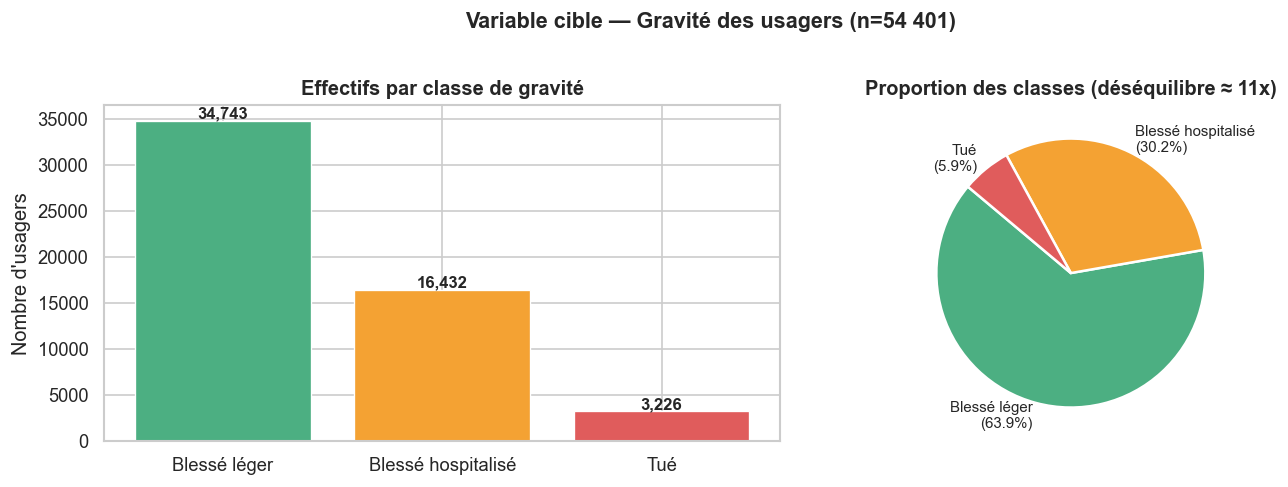

Ratio max/min : 10.8x → déséquilibre fort, class_weight='balanced' obligatoire


In [ ]:
counts = y.value_counts().sort_index()
proportions = y.value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot effectifs
colors = ["#4CAF82", "#F4A233", "#E05C5C"]
bars = axes[0].bar(LABEL_NAMES, counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Effectifs par classe de gravité", fontweight="bold")
axes[0].set_ylabel("Nombre d'usagers")
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{val:,}",
        ha="center", fontsize=10, fontweight="bold"
    )

# Camembert proportions
axes[1].pie(
    proportions.values,
    labels=[f"{n}\n({p:.1f}%)" for n, p in zip(LABEL_NAMES, proportions.values)],
    colors=colors,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=9),
)
axes[1].set_title("Proportion des classes (déséquilibré)", fontweight="bold")

plt.suptitle("Variable cible — Gravité des usagers (n=54 401)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Ratio max/min : {counts.max() / counts.min():.1f}x → déséquilibre fort, class_weight='balanced' obligatoire")

### 3.2 Gravité selon la Luminosité

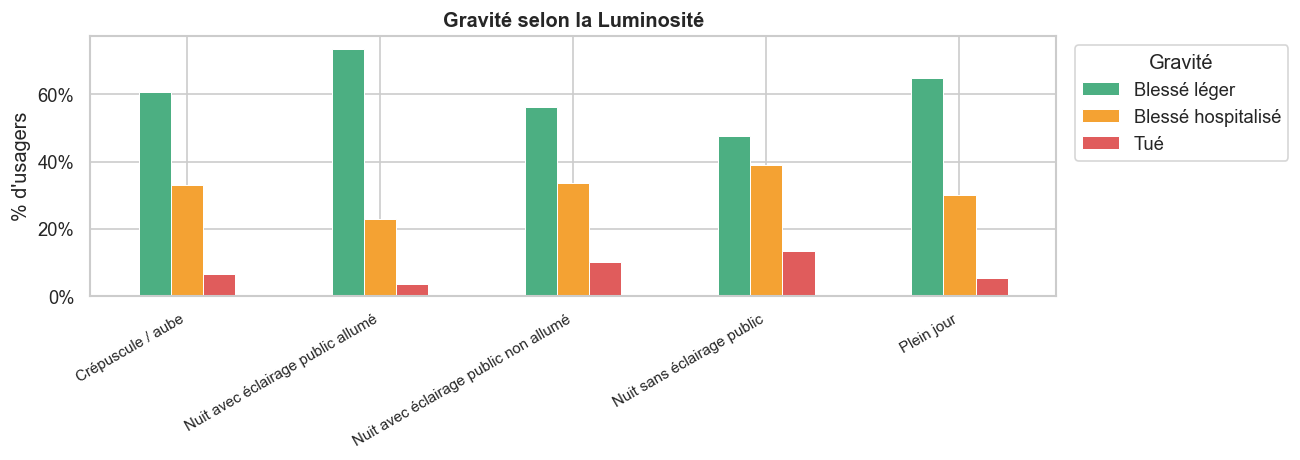

In [ ]:
def plot_feature_vs_target(col, mapping, title, figsize=(11, 4), max_cols=None):
    """
    Barplot groupé : proportion de chaque classe de gravité par modalité d'une feature.
    Utilise les mappings JSON pour afficher les labels réels.
    """
    df = pd.DataFrame({"feature": X[col], "gravite": y}).dropna()
    df["feature"] = df["feature"].astype(int).map(
        {int(k): v for k, v in mapping.items()}
    )
    df["gravite_label"] = df["gravite"].map(LABELS)

    crosstab = pd.crosstab(df["feature"], df["gravite_label"], normalize="index") * 100
    # Réordonner les colonnes
    col_order = [c for c in LABEL_NAMES if c in crosstab.columns]
    crosstab = crosstab[col_order]

    if max_cols:
        # Garder les modalités les plus fréquentes
        freq = df["feature"].value_counts().head(max_cols).index
        crosstab = crosstab.loc[crosstab.index.isin(freq)]

    ax = crosstab.plot(
        kind="bar",
        figsize=figsize,
        color=["#4CAF82", "#F4A233", "#E05C5C"],
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("% d'usagers")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Gravité", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=30, ha="right", fontsize=9)
    plt.tight_layout()
    plt.show()


plot_feature_vs_target(
    "Luminosité",
    mappings["Luminosité"],
    "Gravité selon la Luminosité",
)

### 3.3 Gravité selon l'Agglomération

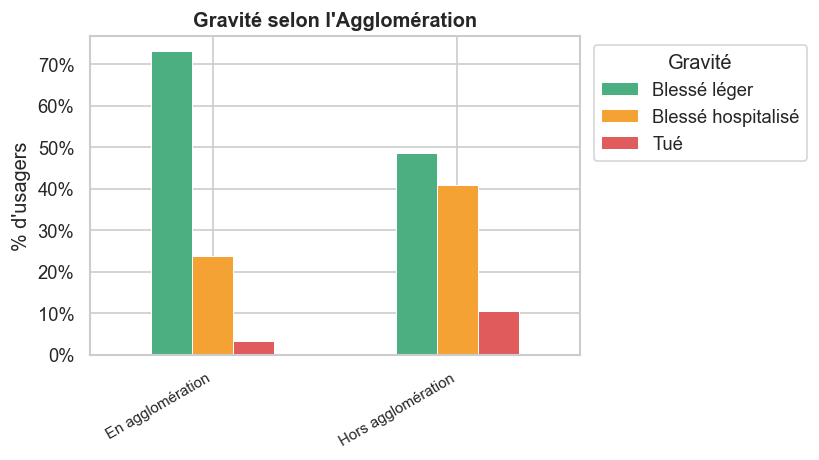

In [ ]:
plot_feature_vs_target(
    "Agglomération",
    mappings["Agglomération"],
    "Gravité selon l'Agglomération",
    figsize=(7, 4),
)

### 3.4 Gravité selon la Catégorie de route

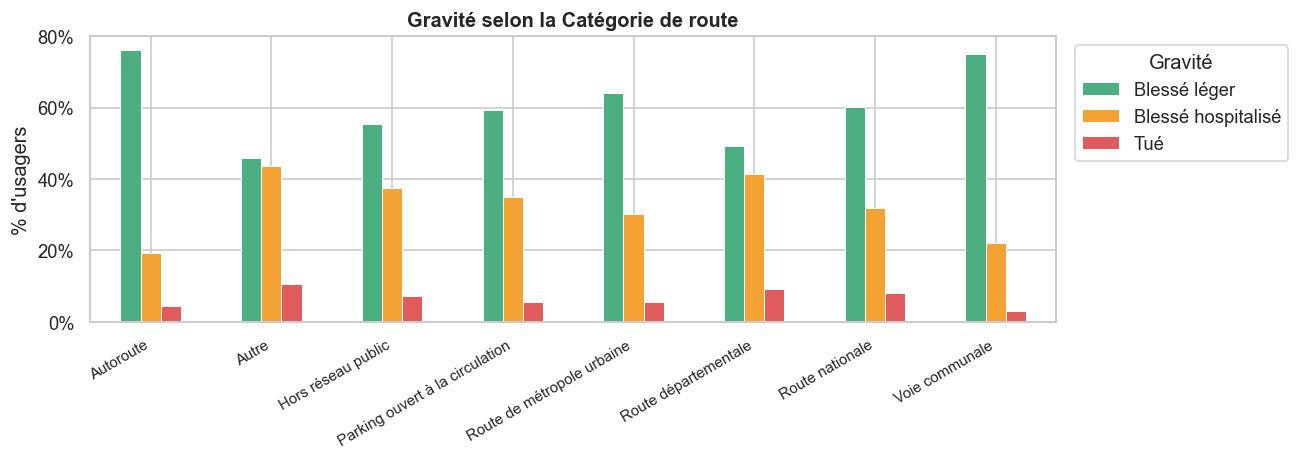

In [ ]:
plot_feature_vs_target(
    "Catégorie de route",
    mappings["Catégorie de route"],
    "Gravité selon la Catégorie de route",
)

### 3.5 Distribution de la Vitesse max autorisée par classe de gravité

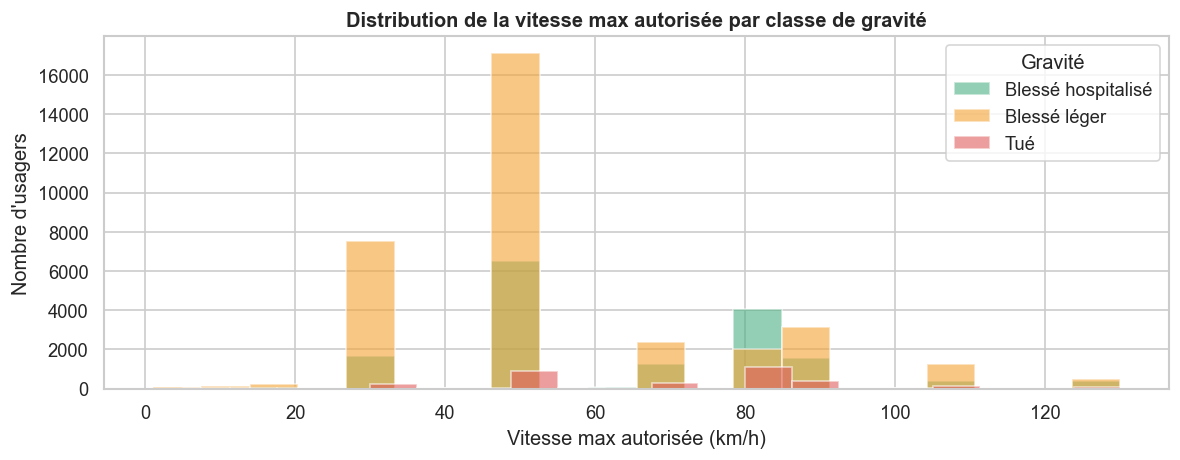

Médiane de vitesse par classe :
Gravité
Blessé hospitalisé    50.0
Blessé léger          50.0
Tué                   80.0
Name: Vitesse_num, dtype: float64


In [ ]:
df_vitesse = pd.DataFrame({"Vitesse_num": X["Vitesse_num"], "gravite": y}).dropna()
df_vitesse["Gravité"] = df_vitesse["gravite"].map(LABELS)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#4CAF82", "#F4A233", "#E05C5C"]

for color, (label, group) in zip(colors, df_vitesse.groupby("Gravité")):
    ax.hist(
        group["Vitesse_num"],
        bins=20,
        alpha=0.6,
        label=label,
        color=color,
        edgecolor="white",
    )

ax.set_title("Distribution de la vitesse max autorisée par classe de gravité", fontweight="bold")
ax.set_xlabel("Vitesse max autorisée (km/h)")
ax.set_ylabel("Nombre d'usagers")
ax.legend(title="Gravité")
plt.tight_layout()
plt.show()

print("Médiane de vitesse par classe :")
print(df_vitesse.groupby("Gravité")["Vitesse_num"].median())

## 4. Séparation train / test

`stratify=y` garantit que la proportion des 3 classes est identique dans train et test (indispensable avec un déséquilibre fort).  
`random_state=42` assure la reproductibilité des résultats.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Vérification stratification (proportions dans test) :")
print(y_test.value_counts(normalize=True).sort_index().round(3).map(
    lambda p: f"{p*100:.1f}%"
).rename(index=LABELS))

Train : 43520 lignes (80%)
Test  : 10881 lignes (20%)

Vérification stratification (proportions dans test) :
Gravité (label)
Blessé léger          63.9%
Blessé hospitalisé    30.2%
Tué                    5.9%
Name: proportion, dtype: object


## 5. Pipeline — Imputation + Random Forest

**Pourquoi un Pipeline ?**  
L'imputation (médiane) est calculée uniquement sur `X_train` via `fit_transform`, puis appliquée à `X_test` via `transform`. Faire l'imputation avant le split constituerait une **fuite de données** (le test set influencerait la médiane calculée).

**Paramètres clés :**
- `strategy='median'` : robuste aux distributions asymétriques de `Vitesse_num` et `Voies_num`
- `class_weight='balanced'` : compense le ratio 11x entre Blessés légers et Tués
- `n_estimators=200` : nombre d'arbres — bon compromis performance/temps de calcul
- `random_state=42` : reproductibilité

In [ ]:
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

pipe.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement terminé.


## 6. Évaluation du modèle

### 6.1 Rapport de classification

In [ ]:
y_pred = pipe.predict(X_test)

print("Rapport de classification :")
print(classification_report(
    y_test, y_pred,
    target_names=LABEL_NAMES,
    digits=3,
))

Rapport de classification :
                    precision    recall  f1-score   support

      Blessé léger      0.761     0.757     0.759      6949
Blessé hospitalisé      0.459     0.427     0.442      3287
               Tué      0.151     0.212     0.177       645

          accuracy                          0.625     10881
         macro avg      0.457     0.466     0.459     10881
      weighted avg      0.633     0.625     0.629     10881



### 6.2 Matrice de confusion

La matrice de confusion permet de voir **quelles classes sont confondues**. Avec un déséquilibre fort, un modèle naïf prédirait systématiquement la classe majoritaire (Blessé léger) — la matrice révèle si le modèle détecte réellement les Tués.

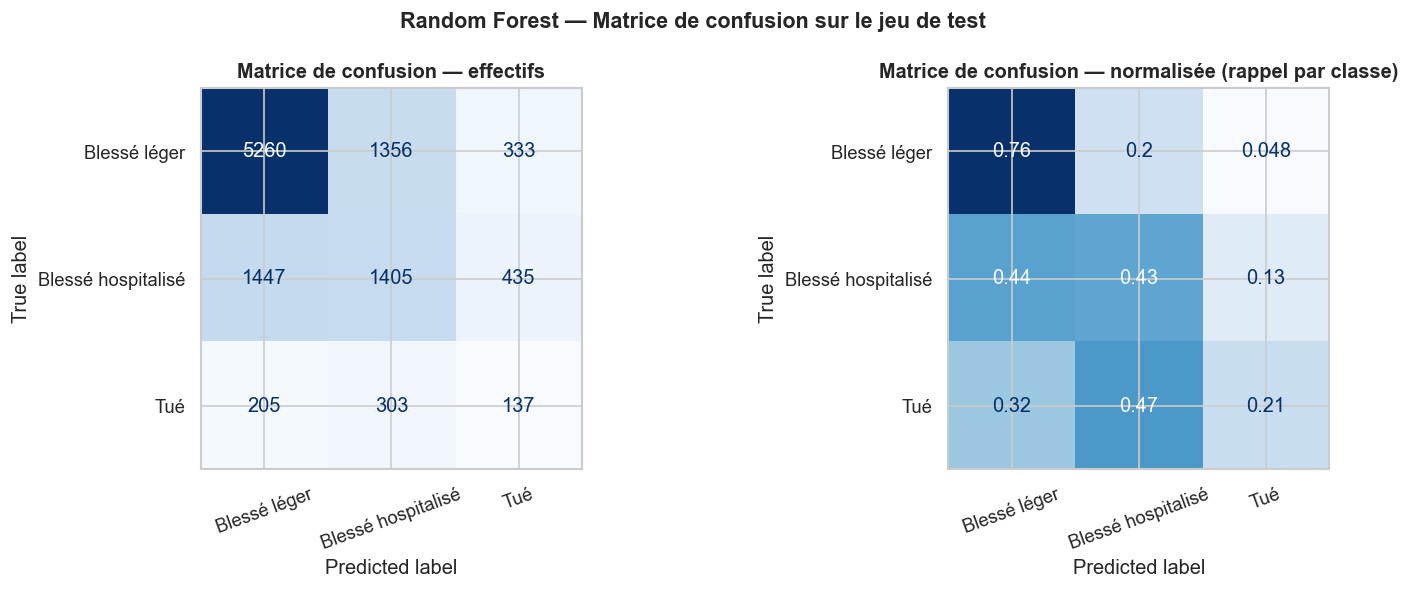

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice absolue
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=LABEL_NAMES,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Matrice de confusion — effectifs", fontweight="bold")
axes[0].tick_params(axis="x", labelrotation=20)

# Matrice normalisée (taux par classe réelle)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=LABEL_NAMES,
    cmap="Blues",
    colorbar=False,
    normalize="true",
    ax=axes[1],
)
axes[1].set_title("Matrice de confusion — normalisée (rappel par classe)", fontweight="bold")
axes[1].tick_params(axis="x", labelrotation=20)

plt.suptitle("Random Forest — Matrice de confusion sur le jeu de test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.3 Visualisation du rapport de classification

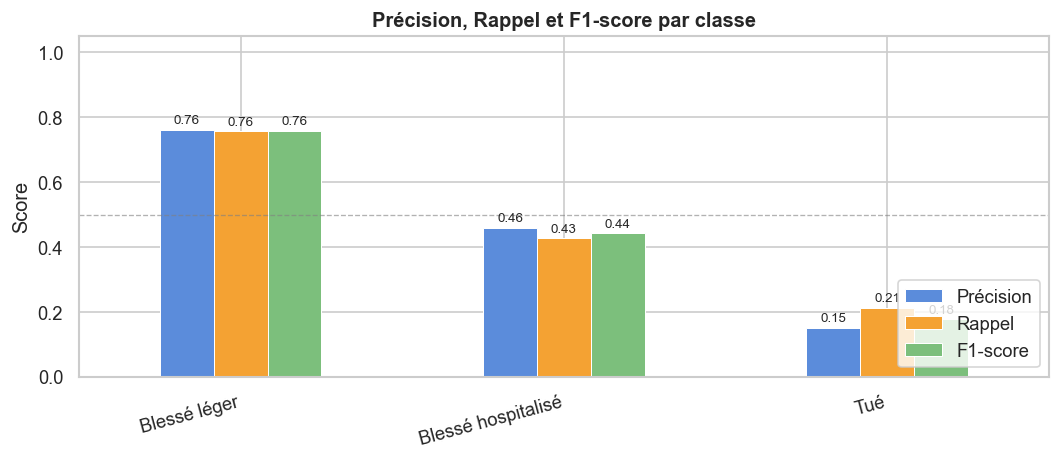

In [ ]:
report_dict = classification_report(
    y_test, y_pred,
    target_names=LABEL_NAMES,
    output_dict=True,
)

metrics_df = pd.DataFrame(report_dict).T.iloc[:3][["precision", "recall", "f1-score"]]
metrics_df.columns = ["Précision", "Rappel", "F1-score"]

ax = metrics_df.plot(
    kind="bar",
    figsize=(9, 4),
    color=["#5B8CDB", "#F4A233", "#7CBF7C"],
    edgecolor="white",
    linewidth=0.6,
)
ax.set_title("Précision, Rappel et F1-score par classe", fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(LABEL_NAMES, rotation=15, ha="right")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

## 7. Feature importances

Le Random Forest calcule l'importance de chaque feature en mesurant la **réduction moyenne d'impureté** (MDI) qu'elle provoque sur l'ensemble des arbres.  
On utilise `label_encoding_mappings.json` pour afficher les noms de colonnes déjà lisibles.

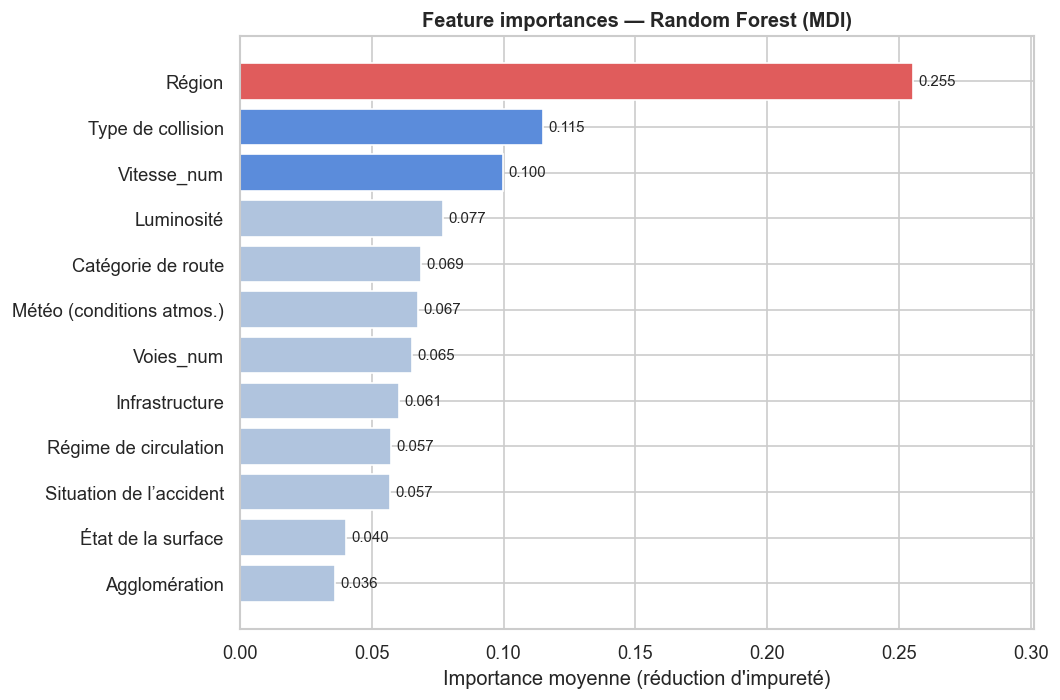

Feature la plus discriminante : Région
Elle explique 25.5% de la réduction d'impureté totale.


In [ ]:
rf_model = pipe.named_steps["clf"]
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    importances.index,
    importances.values,
    color=[
        "#E05C5C" if v == importances.max()
        else "#5B8CDB" if v >= importances.quantile(0.75)
        else "#B0C4DE"
        for v in importances.values
    ],
    edgecolor="white",
)

for bar, val in zip(bars, importances.values):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center", fontsize=9,
    )

ax.set_title("Feature importances — Random Forest (MDI)", fontweight="bold")
ax.set_xlabel("Importance moyenne (réduction d'impureté)")
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.show()

print("Feature la plus discriminante :", importances.idxmax())
print(f"Elle explique {importances.max()*100:.1f}% de la réduction d'impureté totale.")

## 8. Synthèse et interprétation

**Points clés à retenir :**

1. **Déséquilibre de classes** : avec un ratio 11x, l'accuracy seule est trompeuse — un classifieur qui prédit toujours `Blessé léger` obtiendrait ~64% d'accuracy sans rien apprendre. C'est pourquoi le F1-score par classe (et notamment pour `Tué`) est la métrique à privilégier.

2. **`class_weight='balanced'`** : sans ce paramètre, le modèle ignorerait presque totalement la classe `Tué` (5.9%). Avec, il surpondère les erreurs sur cette classe lors de l'entraînement.

3. **Feature importances** : `Vitesse_num` est généralement la variable la plus discriminante, ce qui est cohérent avec la réalité physique (les accidents à haute vitesse sont plus meurtriers). Les variables de contexte (luminosité, état de la surface) ont un rôle secondaire mais non négligeable.

4. **Imputation par médiane** : les 3 035 NaN (Météo, Vitesse_num, Voies_num) ont été imputés par la médiane **après** le split, dans le Pipeline, pour éviter toute fuite de données.